## The basics: MOFA-based multicellular factor analysis

This vignette introduces the core MINA workflow using an unsupervised multicellular factor model based on [MOFA](https://link.springer.com/article/10.1186/s13059-020-02015-1). We use epithelial single-cell data from inflammatory bowel disease to build sample-level multicellular views, learn latent factors across cell types, and interpret these factors as multicellular programs.

In this dataset, the main source of sample-level variability is the enrichment of biopsies for either lamina propria or epithelial compartments. We therefore use this notebook to show how MINA can recover dominant tissue-level structure before moving on to subtler disease-associated programs.

**Learning goals**
- Build multicellular views from single-cell data by aggregating cells into sample-level pseudobulk profiles.
- Fit an unsupervised multicellular factor model across cell types.
- Interpret the dominant factors with respect to tissue compartment and disease.

This is the first notebook in the MINA vignette series.

- Start here if you want the core unsupervised workflow.
- Continue to the `SOFA` vignette if you want to model known sample-level drivers explicitly.
- Continue to the `groups` vignette if you want to model multiple datasets jointly.
- Continue to the `functional` and `functional (guided)` vignette if you want to use prior knowledge to reconstruct multicellular programs

Unless you are already familiarized with the use of factor models for multicellular integration, we encourage you to follow this order


### Some definitions first:

**Multicellular Factor Analysis (MCFA)** is a statistical framework for analyzing single-cell data at the level of whole tissues rather than individual cell types.

Most single-cell approaches analyze cell types independently. MCFA instead models **how multiple cell types vary together across samples (e.g. patients)**, capturing coordinated, tissue-level biology.

---

### Core idea

MCFA treats each cell type (or tissue feature) as a separate *view* of the same sample and applies **group factor analysis** via `MOFA-FLEX` to learn a shared latent space.

- **Input**: per-sample summaries for each cell type (e.g. pseudobulk expression)  
- **Model**: joint factorization across multiple cell-type views  
- **Output**: latent factors interpreted as **multicellular programs**

These programs represent **coordinated gene expression changes across cell types**, rather than cell-intrinsic effects.

---

### What it provides

- **Tissue-centric representation**  
  Samples (patients) are embedded in a low-dimensional space capturing multicellular variation  

- **Multicellular programs**  
  Interpretable factors linking coordinated activity across cell types  

- **Unsupervised analysis**  
  No need to predefine contrasts (e.g. case vs control)  

---

### Conceptual shift

Instead of asking:
> What changes within each cell type?

MFA asks:
> What coordinated patterns across cell types explain differences between samples?

This reframes single-cell data as a **multiview description of tissues**, where biological signals emerge from **inter-cell-type coordination**.

---

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

import mina
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Biological context: epithelial multicellular programs in inflammatory bowel disease

To illustrate how Multicellular Factor Analysis can be used to dissect the main sources of variation across whole tissue samples, we apply MINA to a Crohn’s disease dataset. Crohn’s disease is a chronic inflammatory disorder of the gastrointestinal tract, characterized by patchy, transmural inflammation.

We analyse epithelial cells from the [scIBD atlas](https://www.nature.com/articles/s41586-025-09907-x), focusing on ileal biopsies from [Kong et al., 2023](https://www.sciencedirect.com/science/article/pii/S1074761323000122?via%3Dihub). For this tutorial, we restrict the analysis to a single library preparation protocol; integration across cohorts and technologies is covered in later tutorials.

In this study, Crohn’s disease patients and controls were profiled using scRNA-seq. For patients, biopsies were obtained from both inflamed and non-inflamed regions of the ileum. Each sample is derived from a specific tissue compartment (e.g. epithelial layer or lamina propria), allowing us to focus on epithelial variation across patients and conditions. 

These samples define the unit of analysis, while epithelial cell populations are treated as views summarizing tissue composition.

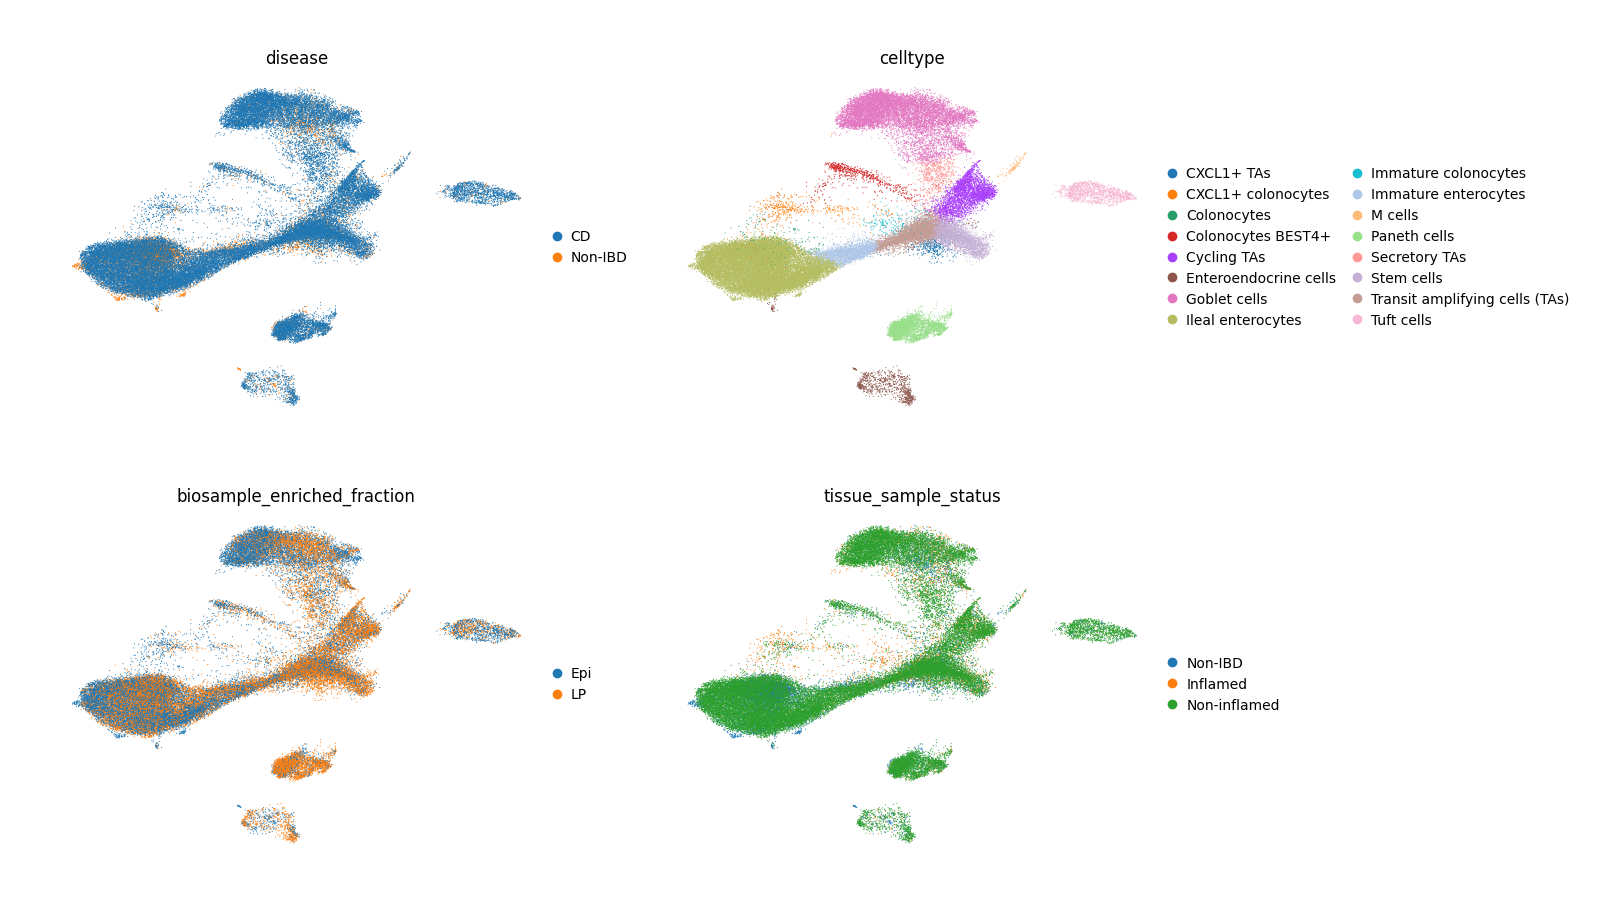

In [2]:
adata = sc.read_h5ad("./data/scIBD/KongEpi_adata_ref.h5ad")
adata = adata[adata.obs["organ"] == "Ileum", :].copy()
sc.pl.umap(adata, color=["disease", 'celltype', "biosample_enriched_fraction", "tissue_sample_status"], frameon=False, ncols=2)

### Build multicellular views from pseudobulked samples

We first convert the single-cell object into a multiview representation. Each biosample becomes one observation, and each cell type becomes one view. Within each view, gene expression is summarized as a pseudobulk profile for that sample and cell type.

This representation is the key input for MINA: it preserves cell-type-resolved information while shifting the analysis to the sample level, where tissue-wide multicellular coordination can be modeled.

In [3]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype")

### Identifying background genes of cell-types

Single-cell data is prone to contamination, here defined as any event that causes a lineage or cell-type to express an unexpected gene (e.g. a cardiomyocyte shouldn't express immune cells marker genes). While background or soup correction is usually done to datasets to deal with this issue, in practice you can expect in pseudobulk expression profiles to find contamination across your cell-types.

In MINA we facilitate the identification of the most obvious source: marker genes of different cell-types expressed within the view.



In [4]:
contaminants_dict = mina.up.get_contaminant_genes(pdata,
                      view_group="celltype",
                      min_count=10,
                      min_total_count=20,
                      large_n=10,
                      min_prop=0.4,
                      lfc_threshold=3,
                      p_threshold=0.001)

In [5]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
#metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
#pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

### Choose filtering thresholds before fitting the model

Before model fitting, it is important to define minimal coverage requirements for each view.

Here we inspect:
- the minimum number of cells contributing to each pseudobulk profile
- the minimum number of biosamples represented in each cell-type view

These thresholds are dataset dependent, but the main goal is the same: keep views that are sufficiently represented across samples while avoiding very sparse or unstable inputs.

Using `decoupler-py` we can inspect the number of cells and read counts of each pseudobulk profile to guide our filtering thresholds.

This is an example for a single cell-type (Tuft cells):


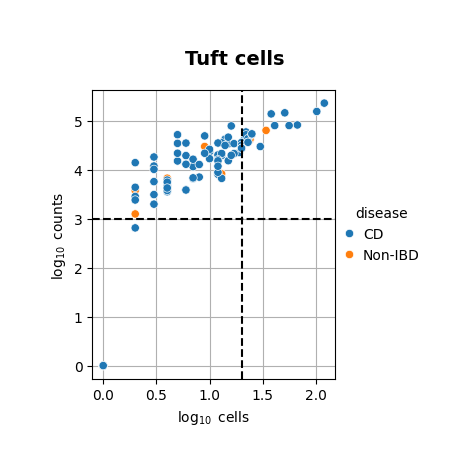

In [6]:
# An example of a single cell-type
dc.pl.filter_samples(anndata_dict["Tuft cells"], groupby=["disease"], min_cells=20, min_counts=1000, figsize=(4, 4))
plt.gcf().suptitle(f"Tuft cells", fontsize=14, fontweight="bold")
plt.show()

We then can apply a filtering to all cell-types

In [7]:
# Making filters
mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=20)

Similarly we can use helping plotting functions to judge how many biosamples do we include in each view

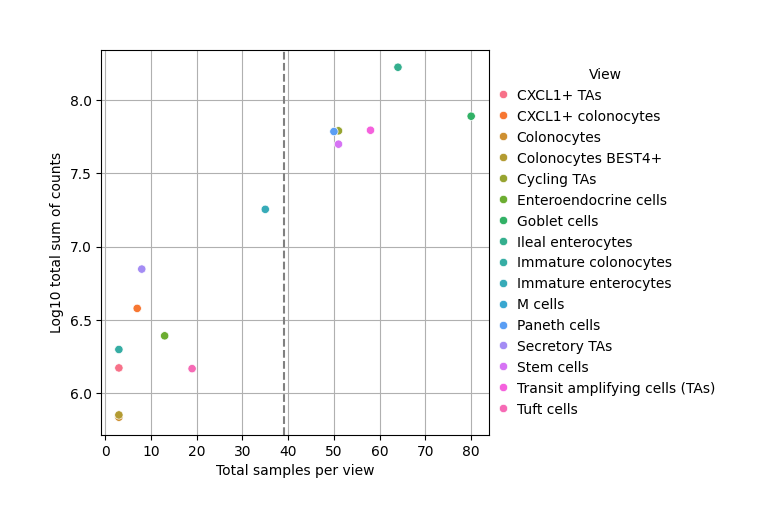

In [8]:
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)
mina.pl.plot_view_samples(anndata_dict, min_samples=min_samples)

In [9]:
# From all the possible samples, let's ask for at least 40%
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)

### Filter genes within each view

We next define which genes are informative enough to retain in each cell-type view. Genes that are rarely detected or have negligible counts across samples tend to add noise without contributing useful structure to the latent model.

The aim of this step is not to aggressively reduce dimensionality, but to remove features that are too sparse to support stable multicellular factor analysis.

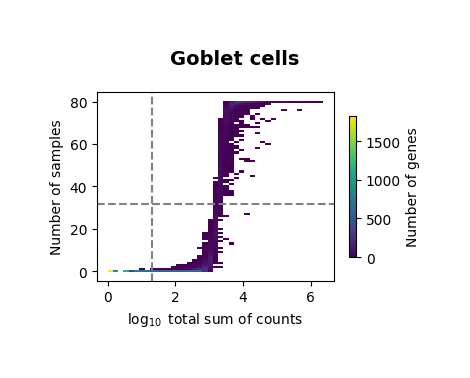

In [10]:
dc.pl.filter_by_expr(anndata_dict["Goblet cells"], min_count=20, min_total_count=20, large_n=0, min_prop=0.4)
plt.gcf().suptitle(f"Goblet cells", fontsize=14, fontweight="bold")
plt.show()

### Final preprocessing before model fitting

After sample- and gene-level filtering, we complete the preprocessing pipeline by:

- removing views with too few retained genes
- filtering samples with low feature coverage (i.e. from 100 genes, a sample covers only a percentage)
- storing raw counts
- normalizing the data (log-normalization)
- selecting highly variable genes - reusing `scanpy` strategies - default "Seurat"
- retaining samples observed across a sufficient number of views

These steps prepare a consistent multiview object for multiview-based modeling.


In [11]:
mina.up.filt.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filt.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filt.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


An important filtering you may want to apply is to filter views by specific genes. This is implemented in `up.filter_genes_by_celltype()`, where you provide the `anndata_dict` and a named list with the same views as in your anndata dictionary and each key contains the set of genes to be filtered out. This is mainly useful to avoid including background genes

In [12]:
contaminants_dict = {ct:values for ct, values in contaminants_dict.items() if ct in anndata_dict.keys()}
mina.up.filter_genes_by_celltype(anndata_dict, contaminants_dict)

In [13]:
anndata_dict

{'Cycling TAs': AnnData object with n_obs × n_vars = 45 × 1256
     obs: 'biosample_id', 'celltype', 'donor_id', 'organ', 'library_preparation_protocol', 'study', 'disease', 'tissue_sample_status', 'celltype_compartment', 'biosample_enriched_fraction', 'psbulk_cells', 'psbulk_counts'
     var: 'features', 'total_counts', 'mean', 'std'
     uns: 'log1p', 'hvg'
     layers: 'psbulk_props', None (.X), 'raw_counts',
 'Goblet cells': AnnData object with n_obs × n_vars = 46 × 1354
     obs: 'biosample_id', 'celltype', 'donor_id', 'organ', 'library_preparation_protocol', 'study', 'disease', 'tissue_sample_status', 'celltype_compartment', 'biosample_enriched_fraction', 'psbulk_cells', 'psbulk_counts'
     var: 'features', 'total_counts', 'mean', 'std'
     uns: 'log1p', 'hvg'
     layers: 'psbulk_props', None (.X), 'raw_counts',
 'Ileal enterocytes': AnnData object with n_obs × n_vars = 33 × 1883
     obs: 'biosample_id', 'celltype', 'donor_id', 'organ', 'library_preparation_protocol', 'study'

### Fit the multicellular factor model

We now convert the processed views into a `MuData` object and fit an unsupervised MOFA model through `MOFA-FLEX`. The resulting latent factors summarize coordinated expression changes across cell types and samples.

For this introductory vignette, we use a compact model with five factors to obtain an interpretable overview of the main multicellular axes of variation.

---
**NOTE**
To avoid issues during model fit, we have provided a helping function `append_view_to_var` that adds a prefix to each feature and makes it suitable for all downstream functions in `MINA`.

---

WARNING	Device cuda is not available. Using default device: cpu


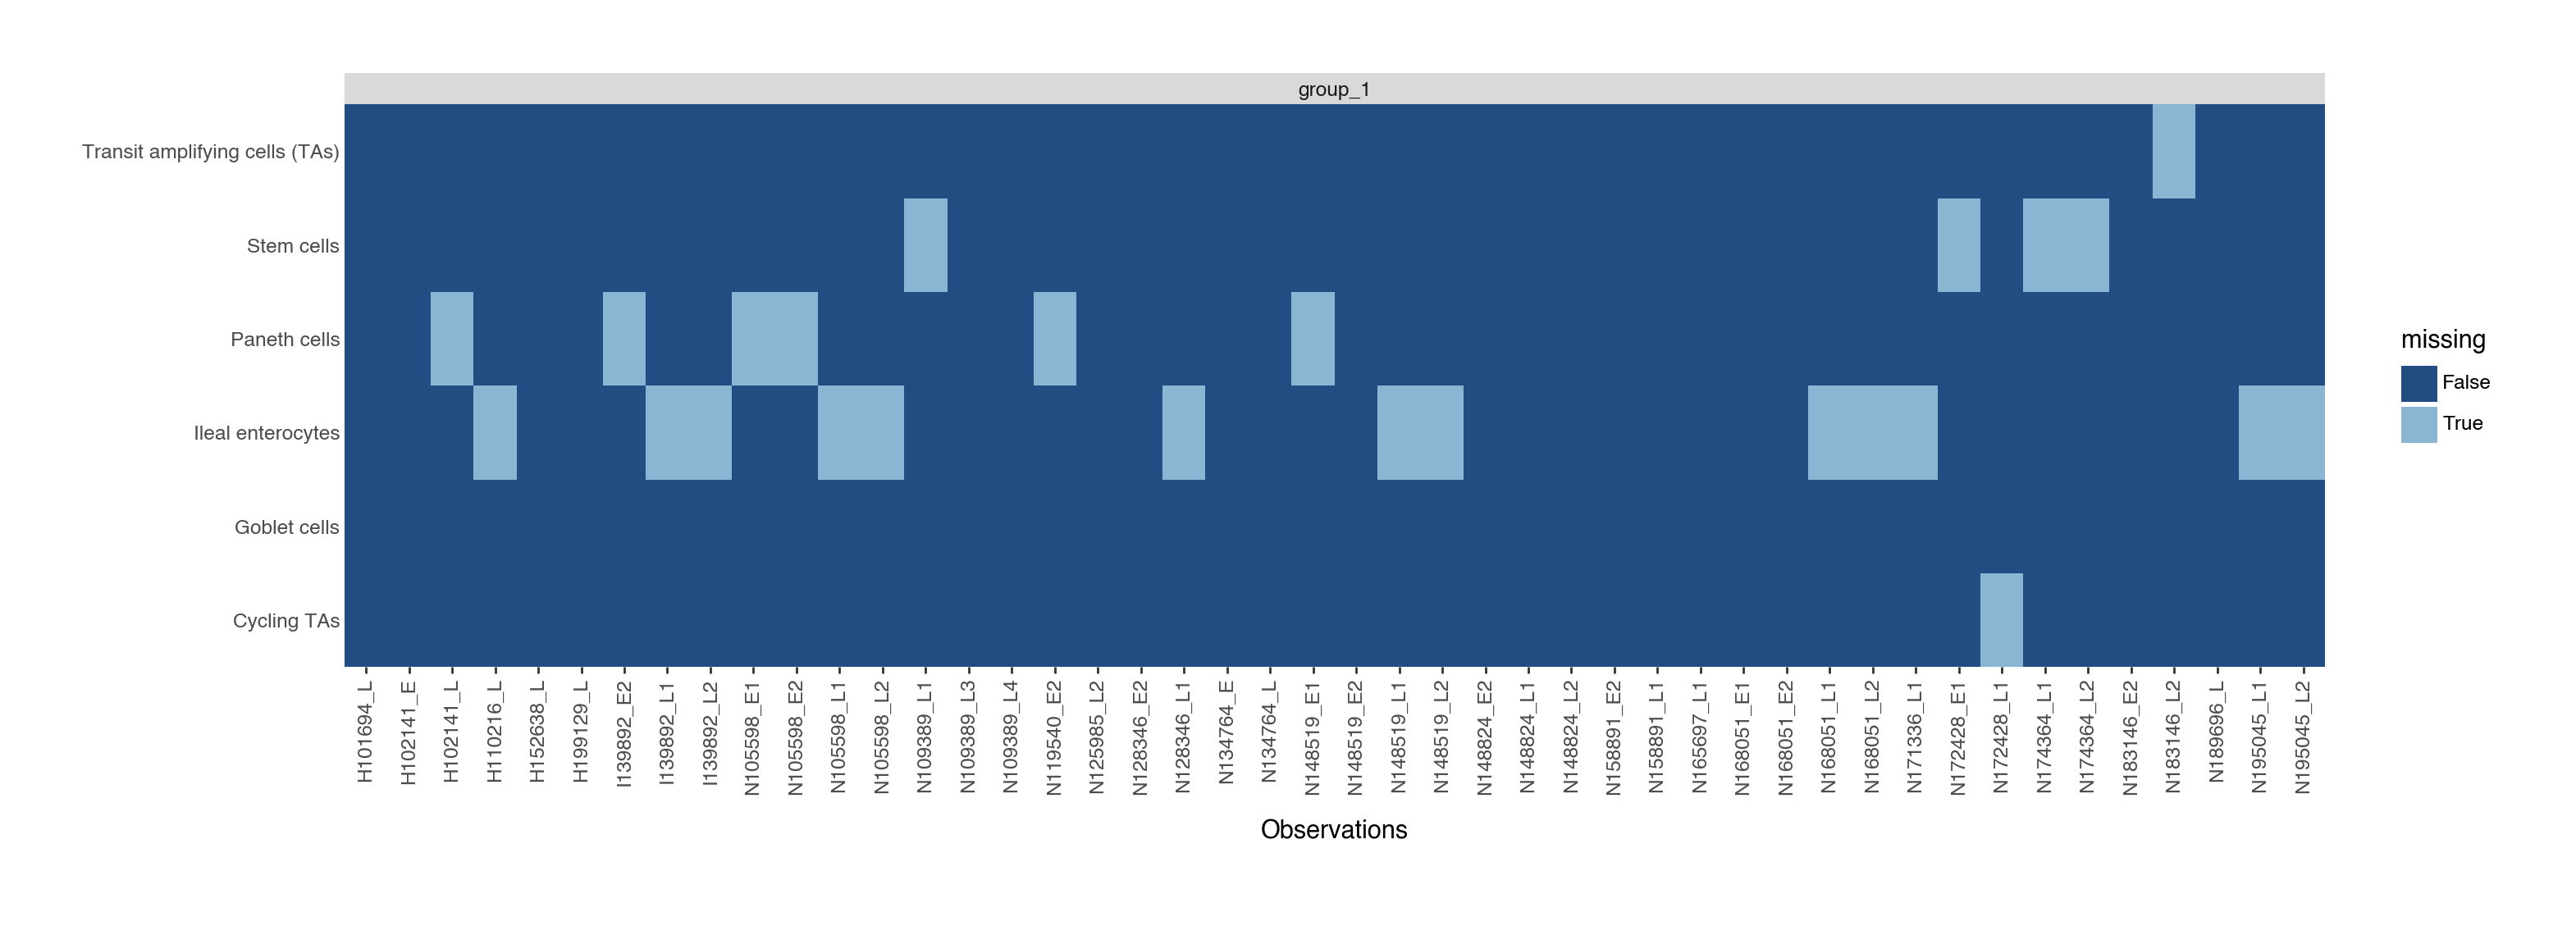

INFO	Initializing factors using 'pca' method...
 25%|██▍       | 2468/10000 [01:38<05:01, 25.02epoch/s, Loss=9.64e+3]


In [14]:
# This is necessary before any model fit!
mina.up.utils.append_view_to_var(anndata_dict)

mdata = md.MuData(anndata_dict)

# Fitting model
model = mf.terms.MofaFlex(n_factors=5, weight_prior="SpikeSlab", init_factors="pca")
model.fit(mdata, seed=42, save_path=False, lr=0.01, early_stopper_patience=1000, likelihoods="Normal")

### Outputs of a factor model

A factor model decomposes data into **latent factors** (capturing sample-level variation) and **loadings** (capturing feature-level contributions), summarizing the main sources of variability.

---

#### 1. Factor scores (sample representation)

- Matrix of size *(samples × factors)*  
- Each value indicates how strongly a sample activates a given factor  
- Interpreted relatively: samples with similar scores share similar underlying structure  

Factor scores define a **low-dimensional embedding of samples**, capturing major axes of variation.

---

#### 2. Explained variance (importance of factors)

- Quantifies how much variability is captured by each factor  
- Can be computed globally or per view / cell-type  

Used to:
- rank factors by importance  
- distinguish dominant vs minor sources of variation  

---

#### 3. Factor loadings (feature weights)

- Matrix of size *(features × factors)*  
- Each value measures how strongly a feature (e.g. gene) contributes to a factor  

Interpretation:
- values ≈ 0 → weak or no contribution  
- large absolute values → strong contribution  
- sign → direction of association  

Loadings provide the **biological interpretation of factors**, linking latent variation to features.

---

### Convert the fitted model into an interoperable `AnnData`

To simplify downstream analysis, we convert the fitted model into an `AnnData` object that integrates latent factors, metadata, and feature-level information in a format compatible with the scverse ecosystem.

In the resulting object:
- `.X` stores factor scores for each sample
- `.obs` stores sample-level metadata
- `.var` stores factor-level information
- `.varm` stores gene loadings
- `.obsm` stores additional view-level outputs generated during model conversion


In [15]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

### Identify the dominant source of variability

One of first questions we can ask to our model is related to the known covariates associated with our factors. This helps you describe the variability of your biosamples in simpler terms.

For this we have implemented in `mina` a simple wrapper of statistical analyses that takes an anndata as input and allows you to perform continuous (linear models) or categorical associations (ANOVAs) between the factor scores and any variable in `.obs`. We provide also the chance to perform mixed-effect models where you can define a random effect.

We first test whether the learned factors are associated with `biosample_enriched_fraction`, which distinguishes lamina propria-enriched from epithelial-enriched biopsies.

This is the main signal we expect to recover in this dataset. Establishing that point is important, because it shows that the leading multicellular factors are capturing major tissue-compartment structure rather than disease alone.

In [16]:
fraction_stats = mina.down.get_associations(amodel, 
                           test_variable = "biosample_enriched_fraction",
                           test_type="categorical",
                           random_effect = None)

print(fraction_stats)

   feature  statistic   p_value  adj_p_value
0  Factor1  20.673988  0.000042     0.000212
1  Factor2   0.073905  0.787006     0.787006
2  Factor3   1.497333  0.227595     0.379325
3  Factor4   8.267650  0.006198     0.015494
4  Factor5   0.968199  0.330510     0.413137


In this case we have three factors that associate with differences in the enriched fraction of the sample.

Standard Scanpy visualizations can then be used to inspect the factor space directly. In this case, we use them to confirm that the major separation between samples is driven by `biosample_enriched_fraction`. For factors with significant associations

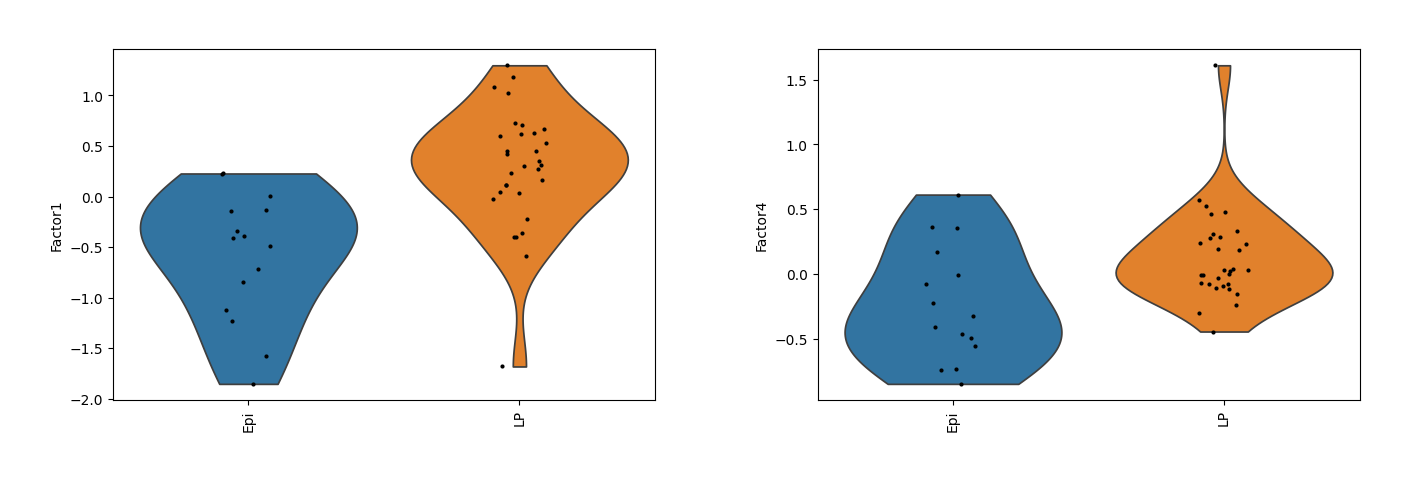

In [ ]:
sc.pl.violin(amodel, 
             ["Factor1","Factor4"], 
             groupby="biosample_enriched_fraction", 
             rotation=90,
             size = 3, 
             dodge = False)

Similarly, we can easily visualize the factor space using functions available in `scanpy`

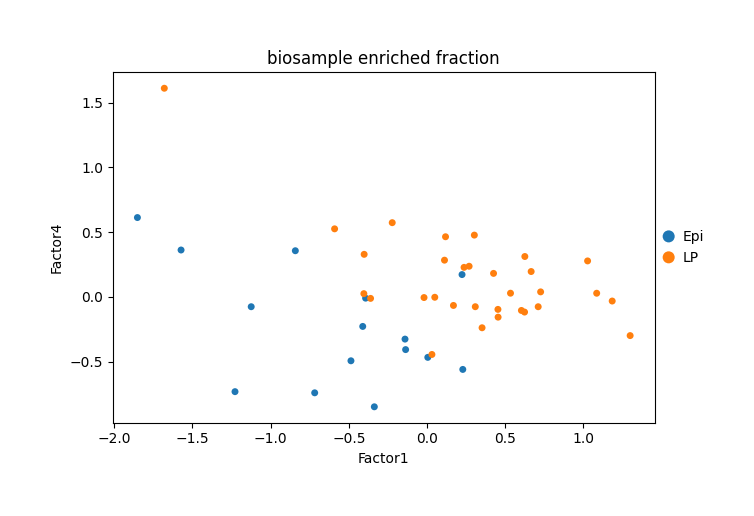

In [18]:
sc.pl.scatter(amodel,
              x = "Factor1",
              y = "Factor4", 
              color  = "biosample_enriched_fraction", 
              size =100)

We can also inspect the variance explained by each latent factor across views using `MOFA-FLEX`'s functions. This provides a complementary summary of how strongly each factor contributes to the multiview structure learned by the model.

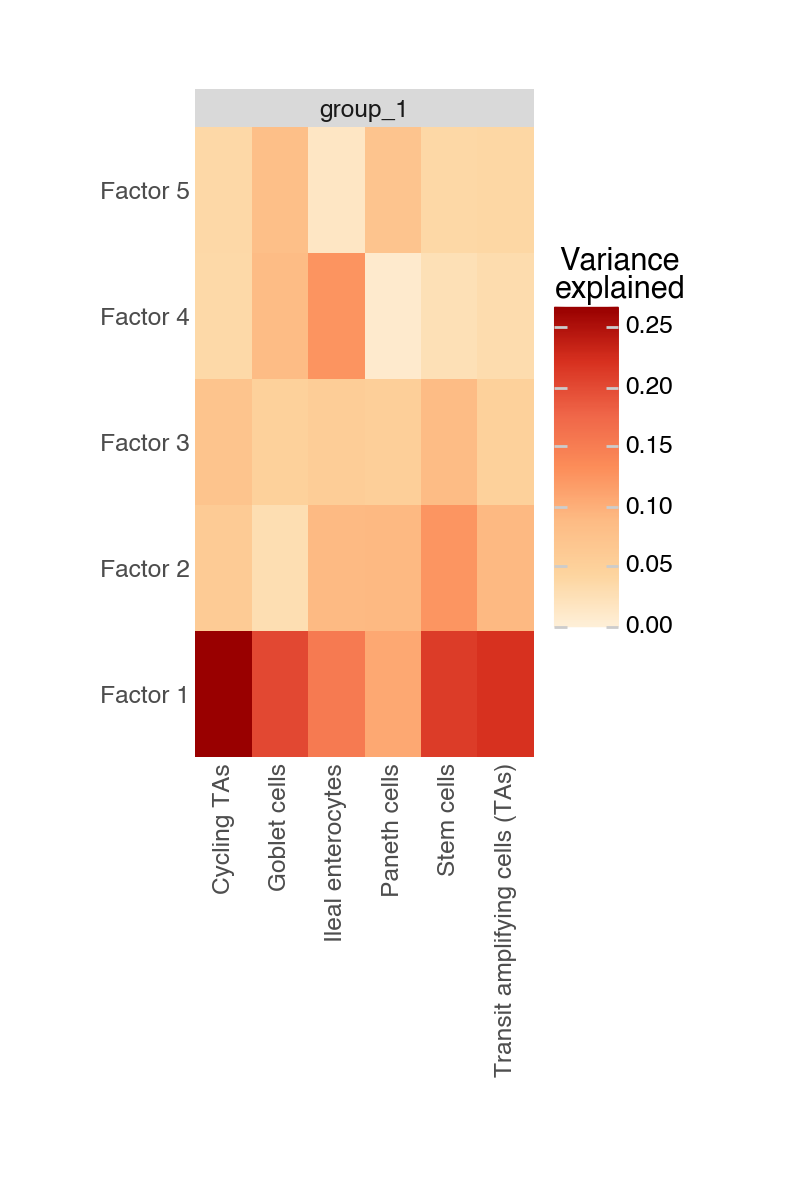

In [19]:
mf.pl.variance_explained(model)

In this case, we can do claims such as: "Factor 1 recovers in a larger extent the variability of all cell types"

To move from factor-level associations to view-level interpretation, we can estimate the total variance associated with a variable of interest. This helps identify which cell types contribute most strongly to the observed compartment-driven variation.

Basically: Which cell type seems to capture more the differences between enriched compartments?

In [20]:
total_var_fraction = mina.down.calc_total_variance(amodel, fraction_stats, pval_thrs=0.05)
total_var_fraction

{'Cycling TAs': feature
 group_1    0.304319
 dtype: float64,
 'Goblet cells': feature
 group_1    0.289474
 dtype: float64,
 'Ileal enterocytes': feature
 group_1    0.282097
 dtype: float64,
 'Paneth cells': feature
 group_1    0.118009
 dtype: float64,
 'Stem cells': feature
 group_1    0.238206
 dtype: float64,
 'Transit amplifying cells (TAs)': feature
 group_1    0.254796
 dtype: float64}

In this case we observed cycling TAs, enterocytes, and Goblet cells are the top three cell types whose variation associates the most with enriched fraction

`mina` also provides functions to summarize associations across multiple metadata variables at once. This is useful for contrasting dominant and secondary sources of variation in the same fitted model.

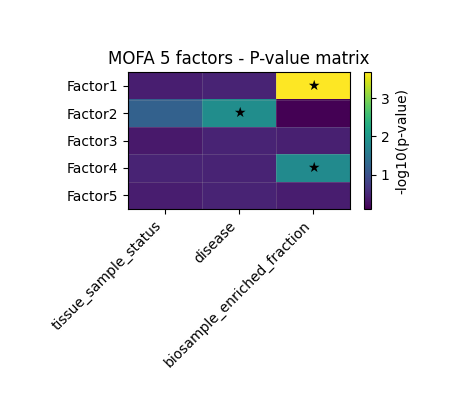

In [21]:
# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mina.down.get_pval_matrix(amodel,["tissue_sample_status", "disease", "biosample_enriched_fraction"])
mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 5 factors - P-value matrix",star_threshold=0.05)
plt.show()

## Characterise a secondary disease-associated factor

Once the dominant compartment effect has been established, we can inspect additional factors associated with disease. In this example, `Factor5` captures a secondary axis of variation linked to inflammatory state.

We therefore use `Factor5` to illustrate how factor loadings can be interpreted biologically across cell types.

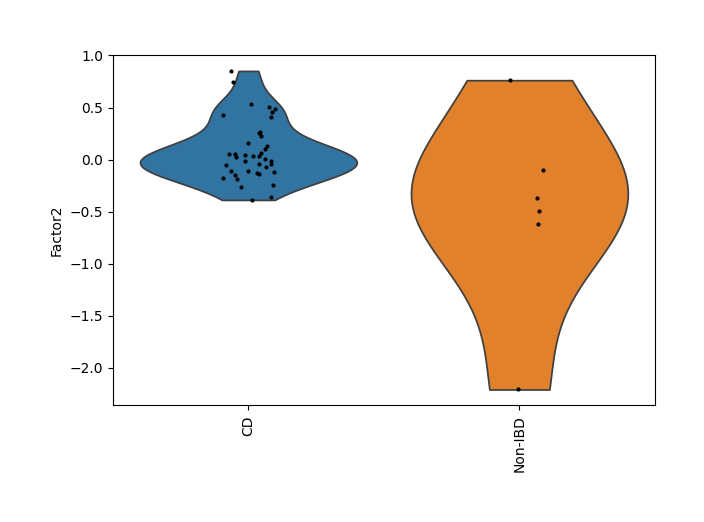

In [22]:
sc.pl.violin(amodel, 
             ["Factor2"], 
             groupby="disease", rotation=90,
             size = 3,
             dodge = False)

Here, positive values of `Factor2` correspond to stronger activation in Crohn's disease samples, whereas negative values correspond to higher activity in healthy samples or relative downregulation in disease.

To interpret this factor, we extract gene loadings across views and summarize them with pathway-level enrichment analysis. This allows us to translate a latent multicellular factor into coordinated biological programs across epithelial cell types.

In [23]:
# Characterizing Factor Loadings
# First we need to make the gene loadings a pandas DataFrame with named columns and indexes

# Wrap as DataFrame for readability - This could be a function - users will forget to do this
gene_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
gene_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
gene_loadings = mina.down.split_by_view(gene_loadings)

In [24]:
gene_loadings["Cycling TAs"]

feature,AAAS,AAMP,ABHD14B,ABHD17A,ABHD17C,ACAA1,ACAP2,ACAT1,ACIN1,ACN9,...,ZNF511,ZNF524,ZNF622,ZNF638,ZNF644,ZNF787,ZNHIT1,ZNHIT6,ZWILCH,ZWINT
Factor1,0.365841,0.661113,-0.175855,0.558414,0.875104,0.179527,0.459405,0.428576,1.270225,-0.649366,...,-0.494416,-0.594059,0.754093,0.921397,0.916223,0.420252,0.003601,1.036137,1.114846,-0.116665
Factor2,0.990622,-0.682665,-0.349951,-0.003845,-0.435138,-0.009744,-0.219014,0.331420,-0.081868,-0.001958,...,-0.000086,0.159283,-0.093614,-0.345226,-0.380833,-0.396587,-0.009434,0.000064,0.931477,0.067277
Factor3,-0.507818,0.009254,-0.313390,0.703148,0.120124,0.502068,0.269213,-0.957457,0.181231,0.102483,...,0.307558,-0.868887,0.148486,0.448276,0.131320,0.137868,0.959635,0.060365,-0.000016,0.466331
Factor4,0.001505,-0.000498,-0.002596,-0.537001,0.825960,-0.012803,-0.061547,-0.001389,0.504664,0.494482,...,0.141070,0.000004,-0.004866,-0.544396,-0.000024,-0.573738,-0.405915,0.271163,0.227129,0.001698
Factor5,-0.803864,-0.054520,-0.764538,0.158692,-0.001153,0.559972,-0.022260,-0.504893,0.059696,0.155212,...,0.873246,0.251951,0.837433,0.235058,-0.124397,0.479116,-0.377331,0.345211,-0.205845,0.328336


Note that the converted gene loadings now look like a expression matrix that we can use to perform regular enrichment analyses as presented in [`decoupler`](https://decoupler.readthedocs.io/en/latest/). 

In this example we will use [PROGENy](https://www.nature.com/articles/s41467-017-02391-6) which collect perturbation-response genes of 14 distinct signaling pathways. By enriching these signatures into gene loadings, we are able to infer signaling pathway activities.

In MINA we provide a wrapper that allows you to perform this across all cell-types

In [25]:
# Now you can run decoupler for each matrix of gene loadings
progeny = dc.op.progeny(organism="human", top=500)
mcp_pws = mina.down.run_ulm_per_view(view_dict=gene_loadings, net=progeny)

Running ULM for view: Cycling TAs
Running ULM for view: Goblet cells
Running ULM for view: Ileal enterocytes
Running ULM for view: Paneth cells
Running ULM for view: Stem cells
Running ULM for view: Transit amplifying cells (TAs)


We also provide some helper plotting functions. They take as input your enrichment analyses and show you the top significant enriched pathways per view.

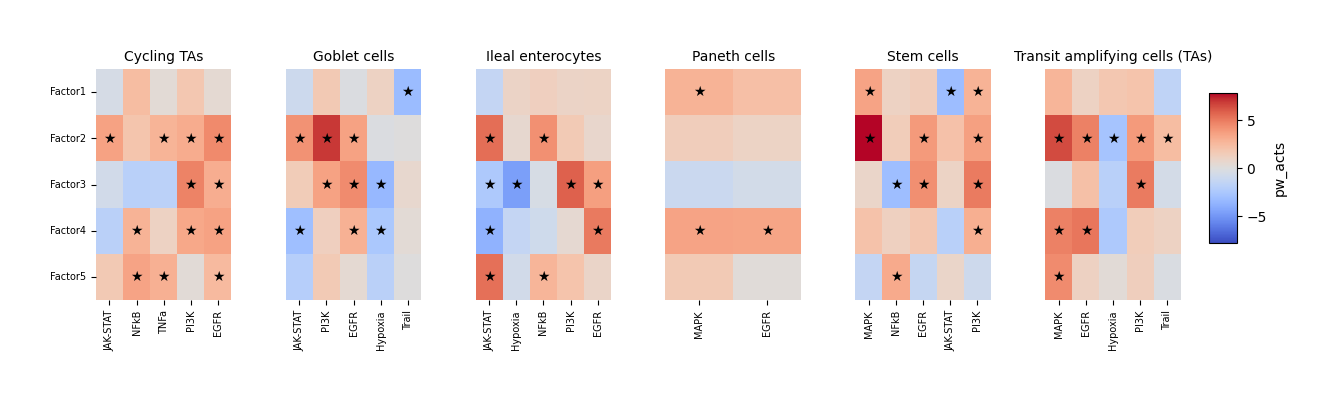

In [26]:
mina.pl.plot_mcell_funcomics(
    result_dict = mcp_pws,
    result_key = "pw_acts",
    pval_key = "pw_padj",
    p_threshold = 0.05,
    top_n = 5,
    cmap = "coolwarm",
    figsize = (14, 3),
    ytick_rotation = 0,
    use_var = True,
    share_color_scale = True,
    center = 0.0,
)

In this example, the disease-associated Factor 2 highlights inflammatory pathway activity in ileal enterocyte populations in Crohn's disease patients. 

Note that we can claim this, because the activity is red (positive) and we know that Crohn's disease patients have higher factor 2 scores.

This illustrates how MINA can move from latent factors to biologically interpretable multicellular programs.

Similarly, it is possible to look at the loadings of specific genes associated with the factor, given the inflammatory response of enterocytes we will look at some of the genes within the TNFa - JAK-STAT - NFkB signature, and compare them with paneth cells that had no activity.

The plotting function in `mina` automatically keeps the features available in views

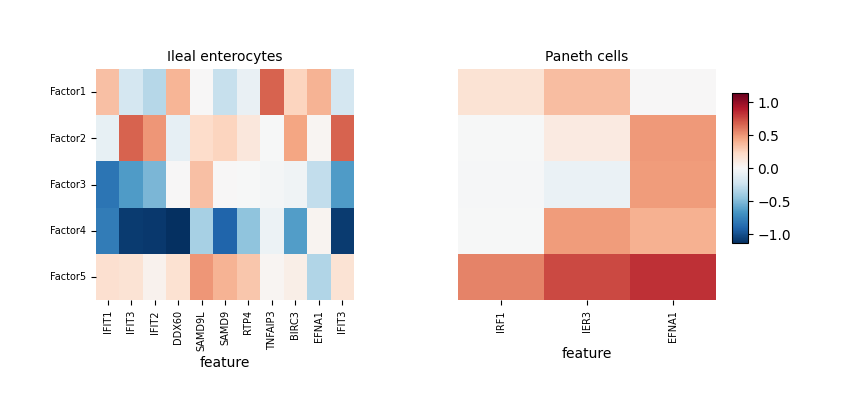

In [27]:
# Get top 10 genes by weight per source
tnfa = progeny[progeny["source"].isin(["JAK-STAT", "NFkB"])]
tnfa = tnfa[tnfa["weight"] > 0]
# Make it absolute and get top 20
tnfa["weight"] = tnfa["weight"].abs()

top_genes = (
    tnfa
    .groupby("source", group_keys=False)
    .apply(lambda x: x.nlargest(35, "weight"))
    .reset_index(drop=True)
)

top_genes_list = top_genes["target"].tolist()

sliced_gene_loadings = {k: gene_loadings[k] for k in ["Ileal enterocytes", "Paneth cells"]}

# Keep only genes present in pathway_membership index
mina.pl.plot_features_per_view(df_dict= sliced_gene_loadings, 
                               features=top_genes_list, 
                               cmap= "RdBu_r",
                               figsize=(8,3))

In the same way, one can focus solely on the genes within a view

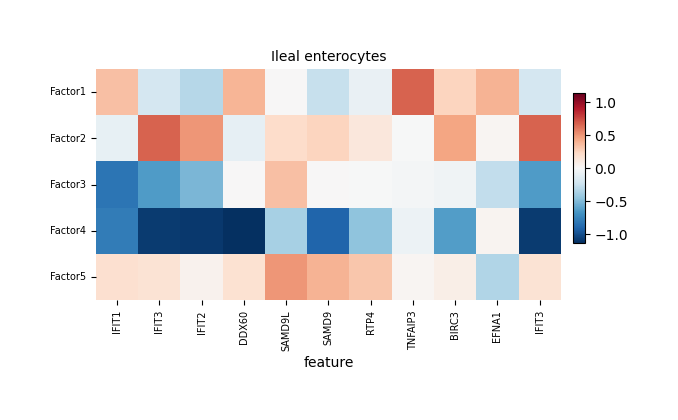

In [28]:
# Keep only genes present in pathway_membership index
mina.pl.plot_features_per_view(df_dict={"Ileal enterocytes" : gene_loadings['Ileal enterocytes']}, 
                               features=top_genes_list, 
                               cmap="RdBu_r",
                               figsize=(6,3))

## Infer multicellular information networks

Multicellular programs summarize coordinated variation across cell types, but they do not directly describe pairwise dependencies between them. To explore this structure further, MINA can derive multicellular information networks from a selected factor. The simple interpretation of this is that now we will use our multicellular program to ask how much of the information of a cell type, allows you to explain the information of the rest.

Here we use the disease-associated factor to estimate directed relationships between cell-type signatures across samples. The resulting network provides a complementary view of how multicellular coordination may be organized within the tissue.

---
**TECHNICAL DESCRIPTION**

Here we build a cell-cell dependency network with directed edges that describe to what extent the molecular profile of one cell-type could predict the profile of each other cell-type. First, we generated cell-type signature matrices per patient sample and study, by enriching the cell-type-specific gene weights of a given factor into the pseudobulk profiles of their respective cell-type. Enrichment was performed with linear models as implemented in decoupleR. To estimate the weight of the incoming edges of the multicellular coordination networks, we built linear mixed models to predict the signatures of a specific cell type with the signatures of the rest. In these models, a covariate of interest can be treated as a random effect. For a given predicted cell-type, the coefficient estimate of each predictor cell-type multiplied by the overall fit of the model was used as the final edge weight. This is done for positive and negative loadings independently. The details are provided in [Lanzer, Ramirez, et. al. 2025](https://www.nature.com/articles/s41467-025-62219-6).

---


 


In [29]:
MINs = mina.down.get_multicell_net(
    test_model = amodel,
    sel_factor = "Factor2",
    random_effect = None,
    standardize = True,
    drop_na = True,
    verbose = True,
)

Here in addition, we focus on the positive set of gene loadings, given that we know that Crohn's disease patients have higher activities of Factor 2

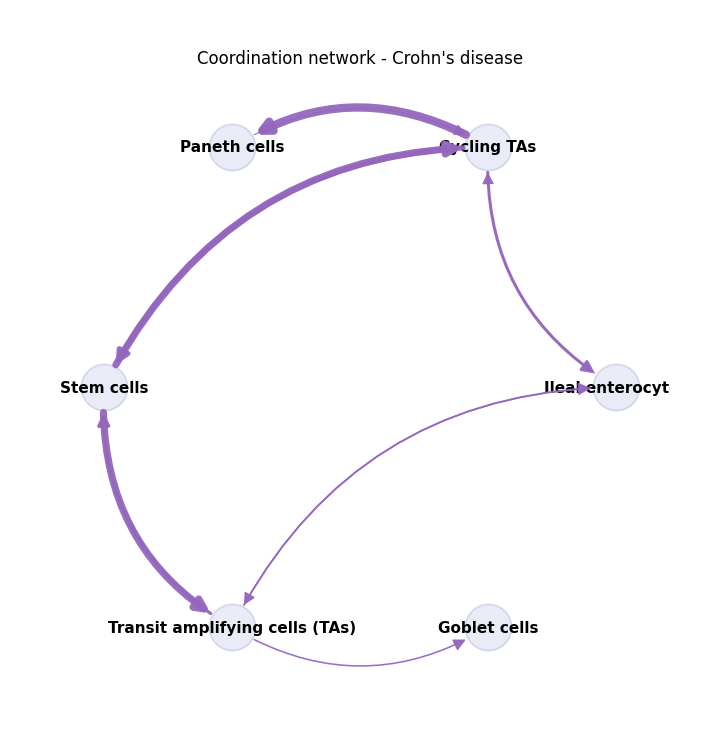

In [30]:
graph_viz = mina.pl.plot_mcell_network(
    df = MINs["positive"],
    weight_col="cor_estimate",
    abs_cutoff=0.2,
    keep_negative=False,
    title="Coordination network - Crohn's disease",
    show_edge_labels = False,
    save_path=None,
    reciprocal_curvature=0.3,
    default_curvature=0.4)

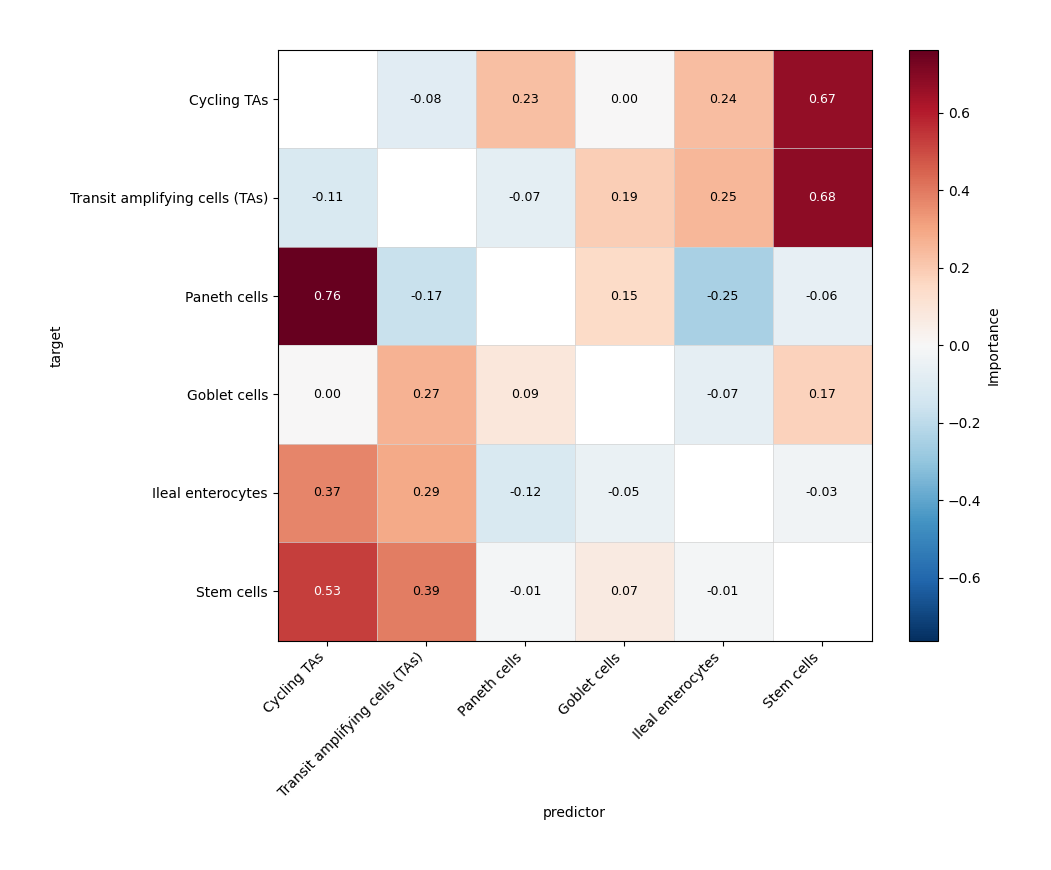

In [31]:
mina.pl.plot_interaction_tileplot(df=MINs["positive"], 
                                  value_col="cor_estimate", row_col="target", col_col="predictor", 
                                  cluster_by = "rows", 
                                  same_order_for_rows_cols=True, 
                                  fill_missing_for_clustering=0.0, 
                                  cmap="RdBu_r", center=0.0, vlim=None, 
                                  show_values=True, value_decimals=2, 
                                  figsize=(10, 8), cbar_label="Importance", 
                                  linewidth=0.5, linecolor="lightgrey", text_kwargs=None)

This analysis allows you to identify which cell-types have a major coordinating role, for example the transcriptional activity of Stem cells is the most predictive of the one of transit amplifying cells

### Potential communication events

Once we have the structure of the coordination network, we can then make the question of which are the potential communication interactions underlying. For this, we will rely on `LIANA+`.

In [32]:
import liana as li

resource = li.rs.select_resource('consensus')
resource["lr_exists"] = 1
resource.head()

,ligand,receptor,lr_exists
0,LGALS9,PTPRC,1
1,LGALS9,MET,1
2,LGALS9,CD44,1
3,LGALS9,LRP1,1
4,LGALS9,CD47,1


In `lr_usage()` we let users explicitly provide a coordination network, together with its respective Factor and gene loadings, and a ligand-receptor resource to provide potential communication events underlying the coordination events. The function ensures that ligand-receptor interactions are coherent both in the direction of expression and also in the cells that can interact.

Although hypothetical, the reported ligands and receptors can be interpreted as the modulators of the tissue state evaluated.

Note that we allow the user to pick top interactions, in order to do this, we provide a simple score (similar as the one given by CellChat), where we multiply the loading of the receptor and the ligand.

In [41]:
comm_summary = mina.down.lr_usage(
    gene_loadings=gene_loadings,
    resource=resource,
    network_df=MINs["positive"].copy(),
    sel_factor="Factor2",
    weight_col="cor_estimate",
    abs_cutoff=0,
    keep_negative=False,
    loading_type="positive",
    n_top=None,
)

comm_summary.head()

,source,target,ligand,receptor,interaction,source_loading,target_loading,source_sign,target_sign,coherent_sign,lr_score
0,Cycling TAs,Goblet cells,COPA,CD74,COPA - CD74,0.516678,0.418423,1,1,1,0.216190
1,Stem cells,Cycling TAs,LGALS3BP,ITGB1,LGALS3BP - ITGB1,0.216279,0.503187,1,1,1,0.108829
2,Stem cells,Cycling TAs,ADAM15,ITGB1,ADAM15 - ITGB1,0.207371,0.503187,1,1,1,0.104346
3,Transit amplifying cells (TAs),Stem cells,CD99,CD81,CD99 - CD81,0.065268,1.506069,1,1,1,0.098298
4,Stem cells,Goblet cells,APP,CD74,APP - CD74,0.132318,0.418423,1,1,1,0.055365


We also provide a simple plotting function that shows the interactions in a more intuitive way.

In [34]:
comm_summary

,source,target,ligand,receptor,interaction,source_loading,target_loading,source_sign,target_sign,coherent_sign,lr_score
0,Cycling TAs,Goblet cells,COPA,CD74,COPA - CD74,0.516678,0.418423,1,1,1,2.161901e-01
1,Stem cells,Cycling TAs,LGALS3BP,ITGB1,LGALS3BP - ITGB1,0.216279,0.503187,1,1,1,1.088286e-01
2,Stem cells,Cycling TAs,ADAM15,ITGB1,ADAM15 - ITGB1,0.207371,0.503187,1,1,1,1.043464e-01
3,Transit amplifying cells (TAs),Stem cells,CD99,CD81,CD99 - CD81,0.065268,1.506069,1,1,1,9.829780e-02
4,Stem cells,Goblet cells,APP,CD74,APP - CD74,0.132318,0.418423,1,1,1,5.536506e-02
5,Ileal enterocytes,Cycling TAs,ADAM9,ITGB1,ADAM9 - ITGB1,0.109793,0.503187,1,1,1,5.524658e-02
6,Stem cells,Cycling TAs,APP,LRP10,APP - LRP10,0.132318,0.385406,1,1,1,5.099621e-02
7,Cycling TAs,Paneth cells,COPA,CD74,COPA - CD74,0.516678,0.070893,1,1,1,3.662863e-02
8,Ileal enterocytes,Transit amplifying cells (TAs),CGN,OCLN,CGN - OCLN,0.030720,0.460419,1,1,1,1.414398e-02
9,Stem cells,Goblet cells,APP,NCSTN,APP - NCSTN,0.132318,0.000396,1,1,1,5.240508e-05


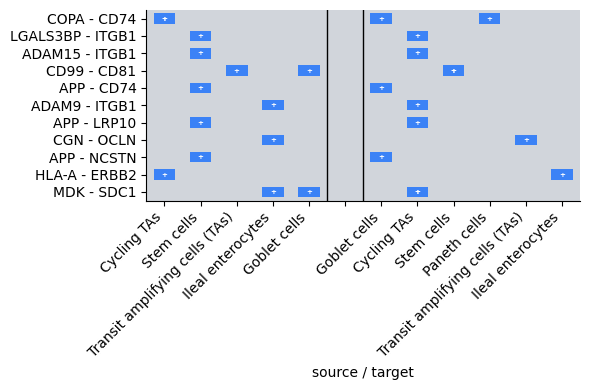

In [35]:
fig, ax = mina.pl.plot_comm_overview(
    plot_df = comm_summary,
    tile_width=0.6,
    tile_height=0.6,
    text_size=5,
    figsize=(6, 4),
    
)

plt.show()

In [ ]:
comm_summary = comm_summary[comm_summary["source"].isin(["Stem cells"])]

Note, however, that this plot loses the information of specific cell-cell interactions. In `MINA` it is possible in addition to plot interactions in a Circos plot. Here focused on the interactions where stem cells are the source signaling cell-type.

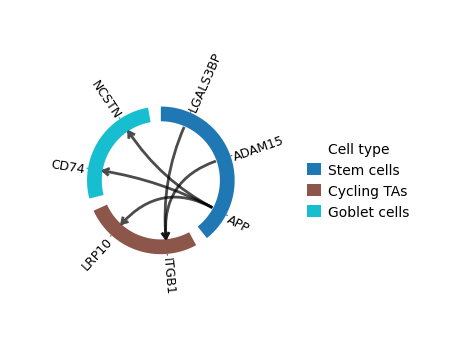

In [63]:
fig, ax = mina.pl.plot_lr_circos(
    plot_df =  comm_summary,
    link_width = 2,
    arrow_height = 8,
    arrow_width = 8,
    gene_label_size = 9,
    sector_gap = 10,
    figsize=(2, 3),
    legend_kwargs={
        "loc": "center left",
        "bbox_to_anchor": (1.4, 0.5),
        "frameon": False,
        "title": "Cell type",
    },
    sector_r_lim = (80, 100),

)

## Summary

In this vignette, we used unsupervised multicellular factor analysis to model coordinated sample-level variation across epithelial cell types in inflammatory bowel disease.

The main conclusion is that the strongest latent structure is associated with `biosample_enriched_fraction`, separating lamina propria-enriched and epithelial-enriched biopsies. After accounting for that dominant axis, additional factors reveal disease-associated multicellular programs that can be interpreted through gene loadings, pathway activity, and cell-type coordination networks.

Use this workflow when you want an unsupervised overview of multicellular structure within a single dataset. If a known sample-level variable dominates the latent space and should be modeled explicitly, the next vignette shows how to do this with `SOFA`.
